# Florida school spine — investigating `schools preprocess` / `schools assemble`

This notebook no longer re-implements the pipeline: it **imports**
`src/regions/florida/sources/schools/{preprocess,assemble}.py` — the way
`assessments.ipynb` imports `assessments/preprocess.py` — runs each stage, and
adds reasonability descriptives the module itself doesn't print. Design &
column dictionary: [`docs/data/florida/schools/README.md`](../../../docs/data/florida/schools/README.md).

| file | grain | written by |
|---|---|---|
| `processed/school_cross_section.parquet` | one row per `msid` | `preprocess` stage 1a |
| `processed/school_year_panel.parquet` | one row per `msid × year` (spring year, 1990–2026) | `preprocess` stages 1a+1b |
| `assembled/schools_treatment.parquet` | one row per `(msid, gcid)` pair | `assemble` stage 2 |
| `assembled/schools_treatment_rollup.parquet` | one row per `msid` | `assemble` stage 2 |

Run with the `311` conda env (geopandas, pandas 3).

Final-panel-level descriptives (covariate coverage, treatment-timing structure, geography of treated schools) now live in [`output/notebooks/descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb) instead of here — this notebook stays focused on *why* the spine and match are built the way they are.


In [1]:
import json
import sys
import warnings
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import geopandas as gpd

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

from src.regions.florida.sources.schools import msid_codes as MC              # noqa: E402
from src.regions.florida.sources.schools import preprocess as PRE             # noqa: E402
from src.regions.florida.sources.schools import assemble as ASM               # noqa: E402
from src.regions.florida.sources.schools.shared import schools_paths          # noqa: E402

P = schools_paths(ROOT)
FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print("  saved", path.relative_to(ROOT))


def describe_num(s, name=""):
    s = pd.to_numeric(s, errors="coerce")
    q = s.quantile([0, .05, .5, .95, 1]).round(2)
    print(f"{name:24s} n={s.notna().sum():>7,}  nan={s.isna().sum():>6,}  "
          f"min={q[0]!s:>8}  p5={q[.05]!s:>8}  med={q[.5]!s:>8}  p95={q[.95]!s:>9}  max={q[1]!s:>10}")


## 1. Stage 1a — spine, crosswalk, classification, coordinates

`build_cross_section` needs the classified, geocoded MSID spine; walking
through the pieces here (rather than only calling the top-level
`run_schools_preprocess`) so each stage's output can be inspected.


In [2]:
msid_raw = PRE.load_msid(ROOT)
msid_id = PRE.compose_ncessch(msid_raw)
print(f"MSID {msid_id.shape[0]:,} rows | ncessch sentinel "
      f"{msid_id['ncessch'].isna().mean():.1%} | ncessch_shared rows {int(msid_id['ncessch_shared'].sum())}")

ccd_directory = PRE.tidy_ccd_directory(ROOT)
msid_classified = PRE.decode_classification(msid_id, ccd_directory)
print("\ngrade_low_source:", msid_classified["grade_low_source"].value_counts().to_dict())
print("serves_tested_grades:", msid_classified["serves_tested_grades"].value_counts(dropna=False).to_dict())
print("flags (n True):", {c: int(msid_classified[c].sum()) for c in
      ["is_regular", "is_alternative", "is_charter", "is_magnet", "is_virtual"]})


MSID 7,204 rows | ncessch sentinel 9.4% | ncessch_shared rows 72



grade_low_source: {'msid_grade_code': 6135, 'none': 902, 'ccd_directory': 167}
serves_tested_grades: {np.True_: 5720, <NA>: 902, np.False_: 582}
flags (n True): {'is_regular': 4997, 'is_alternative': 957, 'is_charter': 1292, 'is_magnet': 669, 'is_virtual': 324}


In [3]:
edge = PRE.load_edge(root=ROOT)
msid_geo = PRE.resolve_coordinates(msid_classified, edge)
print("geom_source:", msid_geo["geom_source"].value_counts().to_dict())
print("geocode_pending (active, no coordinate):", int(msid_geo["geocode_pending"].sum()))
describe_num(msid_geo["geom_disagree_m"], "EDGE<->MSID gap (m)")
print(f"  > 250 m apart: {(msid_geo['geom_disagree_m'] > 250).mean():.1%}")


geom_source: {'edge': 4325, 'msid': 1659, 'none': 1220}
geocode_pending (active, no coordinate): 239
EDGE<->MSID gap (m)      n=  4,274  nan= 2,930  min=     0.1  p5=     3.8  med=    48.6  p95=   633.52  max=  355394.8
  > 250 m apart: 4.8%


### 1.1 Crosswalk reasonability against independent sources

`school_barrier_features.parquet` (from `barriers.ipynb`) carries EDGE's own
`NCESSCH` for 2024–25 — how many composed ids match one of those? And is every
tested `msid` in the spine (bar the known district-78/80 state colleges)?


In [4]:
assess_school = PRE.load_assessment_schools(ROOT)
edge_nc = set(pd.read_parquet(
    ROOT / "data/florida/schools/processed/school_barrier_features.parquet",
    columns=["NCESSCH"])["NCESSCH"].astype(str))
comp = msid_id.loc[msid_id["ncessch"].notna(), ["ncessch", "ACTIVITY_CODE"]]
print(f"composed ncessch matches an EDGE id: all {comp['ncessch'].isin(edge_nc).mean():.1%}   "
      f"active-only {comp.loc[comp.ACTIVITY_CODE=='A', 'ncessch'].isin(edge_nc).mean():.1%}")

tested = set(assess_school["msid"])
missing = sorted(tested - set(msid_id["msid"]))
print(f"tested msid absent from spine: {len(missing)} / {len(tested)}  "
      f"districts {sorted({m[:2] for m in missing})}  (78/80 = state colleges, expected)")


composed ncessch matches an EDGE id: all 66.3%   active-only 86.0%


tested msid absent from spine: 44 / 5039  districts ['05', '06', '16', '17', '29', '35', '45', '48', '61', '64', '77', '78', '80']  (78/80 = state colleges, expected)


## 2. Cross-section & operation panel


In [5]:
cross_section = PRE.build_cross_section(msid_geo, assess_school)
panel_skeleton = PRE.build_operation_panel(msid_geo, assess_school)
print("cross_section:", cross_section.shape, "| unique msid:", cross_section["msid"].is_unique)
print("panel skeleton:", panel_skeleton.shape,
      "| operating rows:", int(panel_skeleton["in_operation"].sum()),
      "| conflict->True:", int((panel_skeleton["in_operation_src"] == "conflict").sum()))

print("\nby activity x school_type:")
print(pd.crosstab(cross_section["activity"], cross_section["school_type"]).to_string())

# "operating schools per spring year" now lives in descriptive_statistics.ipynb
# (panel-balance section) rather than here.


cross_section: (7204, 30) | unique msid: True
panel skeleton: (266548, 5) | operating rows: 176800 | conflict->True: 64

by activity x school_type:
school_type  adult  combination  elementary  middle_jr_high  not_yet_assigned  other  senior_high
activity                                                                                         
active         122          909        1863             548                 0    424          917
closed         190          269         479             206                 0    530          596
future           0           12          11               4               103     12            9


## 3. Stage 1b — Cluster-A covariates


In [6]:
race_shares = PRE.tidy_ccd_enrollment_race(ROOT)
crdc_swd = PRE.tidy_crdc_swd(ROOT)
crdc_lep = PRE.tidy_crdc_lep(ROOT)
edfacts = PRE.tidy_edfacts(ROOT)
panel = PRE.join_covariates(panel_skeleton, cross_section, ccd_directory, race_shares, crdc_swd, crdc_lep, edfacts)

for name, tbl in [("ccd_directory", ccd_directory), ("race_shares", race_shares),
                  ("crdc_swd", crdc_swd), ("crdc_lep", crdc_lep), ("edfacts", edfacts)]:
    print(f"{name:14s}", "present" if tbl is not None else "MISSING — run `schools fetch --subsource ...`")

describe_num(ccd_directory["enrollment"], "enrollment")
describe_num(ccd_directory["pupil_teacher_ratio"].clip(upper=60), "pupil_teacher_ratio")
describe_num((ccd_directory["frpl_n"] / ccd_directory["enrollment"]).clip(0, 1.5), "frpl_n / enrollment")
describe_num(race_shares["pct_black"], "pct_black")
describe_num(crdc_swd["pct_swd"], "pct_swd")
describe_num(crdc_lep["pct_ell"], "pct_ell")
describe_num(edfacts["read_prof_midpt"], "read_prof_midpt")


ccd_directory  present
race_shares    present
crdc_swd       present
crdc_lep       present
edfacts        present
enrollment               n=126,342  nan= 5,529  min=     0.0  p5=    11.0  med=   633.0  p95=   1870.0  max=   12730.0
pupil_teacher_ratio      n=114,358  nan=17,513  min=     0.0  p5=    6.28  med=    16.3  p95=     23.5  max=      60.0
frpl_n / enrollment      n=100,133  nan=31,738  min=     0.0  p5=    0.08  med=    0.56  p95=     0.93  max=       1.5
pct_black                n=122,241  nan= 1,836  min=     0.0  p5=    0.01  med=    0.19  p95=     0.85  max=      1.75
pct_swd                  n= 23,665  nan=    71  min=     0.0  p5=    0.02  med=    0.13  p95=     0.39  max=      1.22
pct_ell                  n= 23,665  nan=    71  min=     0.0  p5=     0.0  med=    0.05  p95=     0.37  max=       1.0
read_prof_midpt          n= 41,275  nan=   105  min=    -3.0  p5=    10.0  med=    52.0  p95=     84.0  max=      99.5


### 3.1 Reasonability: CCD enrollment vs. assessment test-takers

Each tested grade feeds both ELA and Math, so the sum ≈ 2×(tested-grade
population) ≈ enrollment for a 3-grade elementary school → a ratio near 1 is
expected; a wide tested span pushes it above 1.


In [7]:
ntest = (assess_school[assess_school.subject.isin(["ELA", "MATH"])]
         .groupby(["msid", "year"])["n_students"].sum().rename("n_tested_elamath"))
cmp = (panel.merge(ntest, on=["msid", "year"], how="inner")
       .loc[lambda x: x["enrollment"].gt(0) & x["n_tested_elamath"].gt(0)])
ratio = cmp["n_tested_elamath"] / cmp["enrollment"]
print(f"ELA+Math test-takers / CCD enrollment (n={len(cmp):,}): "
      f"median {ratio.median():.2f}  p10 {ratio.quantile(.1):.2f}  p90 {ratio.quantile(.9):.2f}")
print("extreme ratios (>3 or <0.1):", int(((ratio > 3) | (ratio < 0.1)).sum()), "rows")


ELA+Math test-takers / CCD enrollment (n=77,166): median 0.98  p10 0.49  p90 1.87
extreme ratios (>3 or <0.1): 766 rows


## 4. Run the full `preprocess` (validates + persists)

Re-derives everything above through the single entry point and writes
`school_cross_section.parquet` / `school_year_panel.parquet` + `schools.json`.


In [8]:
report = PRE.run_schools_preprocess(root=ROOT)
print(json.dumps({k: v for k, v in report.items() if k not in ("panel_columns", "saved")}, indent=1, default=str))
for k, v in report["saved"].items():
    print("wrote", Path(v).relative_to(ROOT))


{
 "generated_at_utc": "2026-09-17T12:50:10+00:00",
 "generated_by": "src/regions/florida/sources/schools/preprocess.py",
 "panel_years": [
  1990,
  2026
 ],
 "crs": "EPSG:3087",
 "rows": {
  "cross_section": 7204,
  "panel": 266548
 },
 "crosswalk": {
  "ncessch_sentinel_share": 0.09383675735702388,
  "ncessch_shared_rows": 72,
  "assessment_msid_missing_state_colleges": [
   "770000",
   "780002",
   "780004",
   "780005",
   "780006",
   "780007",
   "780008",
   "780009",
   "780011",
   "780012",
   "780014",
   "780016",
   "780017",
   "780020",
   "780027",
   "780028",
   "780029",
   "780032",
   "800005",
   "800007",
   "800011",
   "800020",
   "800025",
   "800026"
  ],
  "assessment_msid_missing_pre2015_reporting_codes": [
   "051005",
   "051006",
   "060952",
   "063611",
   "063671",
   "063772",
   "063831",
   "160182",
   "160220",
   "163003",
   "170612",
   "174663",
   "295023",
   "359008",
   "450112",
   "480763",
   "483100",
   "485781",
   "619004",
   "

## 5. Stage 2 — `schools assemble` (school ↔ barrier point-only match)

Algorithms 1–2 (`euclid_nearest`, `buffer_dose`) first; §7 below verifies
algorithms 3–5 (`road_id` / `same_route` / `school_side` / `wall_side`),
which `run_schools_assemble` (§6) already computes in the same call — all
three treatment-timing tiers land in one persisted rollup, not two
separate stages.


In [9]:
placed = ASM.load_placed_cross_section(ROOT)
barriers = ASM.load_barriers(ROOT)
pair, rollup = ASM.match_barriers_point(placed, barriers)
print(f"{len(pair):,} pairs | {rollup['msid'].nunique():,} placed schools | "
      f"{pair.loc[pair.category.eq('fdot_barrier'), 'timing_unknown'].mean():.1%} undated fdot pairs")

rows = [(r, int((rollup["nearest_fdot_dist_m"] <= r).sum()),
         f"{(rollup['nearest_fdot_dist_m'] <= r).mean():.1%}")
        for r in (100, 200, 300, 500, 1000, 2000, 5000)]
print(pd.DataFrame(rows, columns=["buffer_m", "n_schools", "share_placed"]).to_string(index=False))
describe_num(rollup["nearest_fdot_dist_m"], "nearest FDOT wall (m)")


2,173 pairs | 5,984 placed schools | 2.5% undated fdot pairs
 buffer_m  n_schools share_placed
      100         18         0.3%
      200         72         1.2%
      300        116         1.9%
      500        220         3.7%
     1000        578         9.7%
     2000       1317        22.0%
     5000       3017        50.4%
nearest FDOT wall (m)    n=  5,984  nan=     0  min=    35.0  p5=  607.87  med= 4902.85  p95= 82715.25  max=  164989.6


schools within 1 km of a wall, by district (top 8):
{'MIAMI-DADE': 124, 'BROWARD': 97, 'ORANGE': 79, 'PALM BEACH': 73, 'HILLSBOROUGH': 69, 'DUVAL': 33, 'PINELLAS': 25, 'BREVARD': 12}


  saved output/figures/florida/schools_barrier_match.png


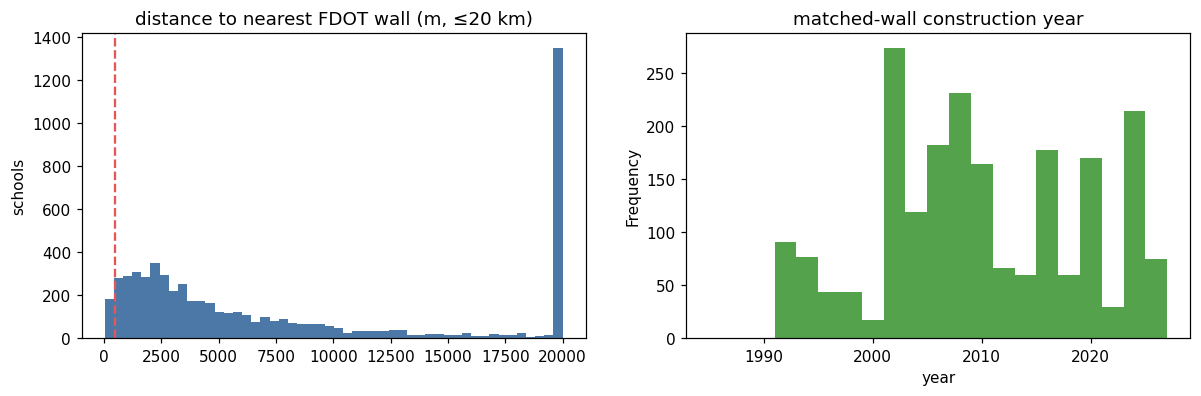

In [10]:
near = rollup[rollup.ever_near_wall_1000m].merge(cross_section[["msid", "district_name"]], on="msid", how="left")
print("schools within 1 km of a wall, by district (top 8):")
print(near["district_name"].value_counts().head(8).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
rollup["nearest_fdot_dist_m"].clip(upper=20000).plot.hist(bins=50, ax=ax[0], color=BLUE)
ax[0].axvline(500, color=RED, ls="--")
ax[0].set(title="distance to nearest FDOT wall (m, ≤20 km)", ylabel="schools")
pair.loc[pair.category.eq("fdot_barrier"), "treat_year"].dropna().plot.hist(
    bins=range(1985, 2028, 2), ax=ax[1], color=GREEN)
ax[1].set(title="matched-wall construction year", xlabel="year")
savefig(fig, "schools_barrier_match.png")


  saved output/figures/florida/schools_algo1_algo2.png


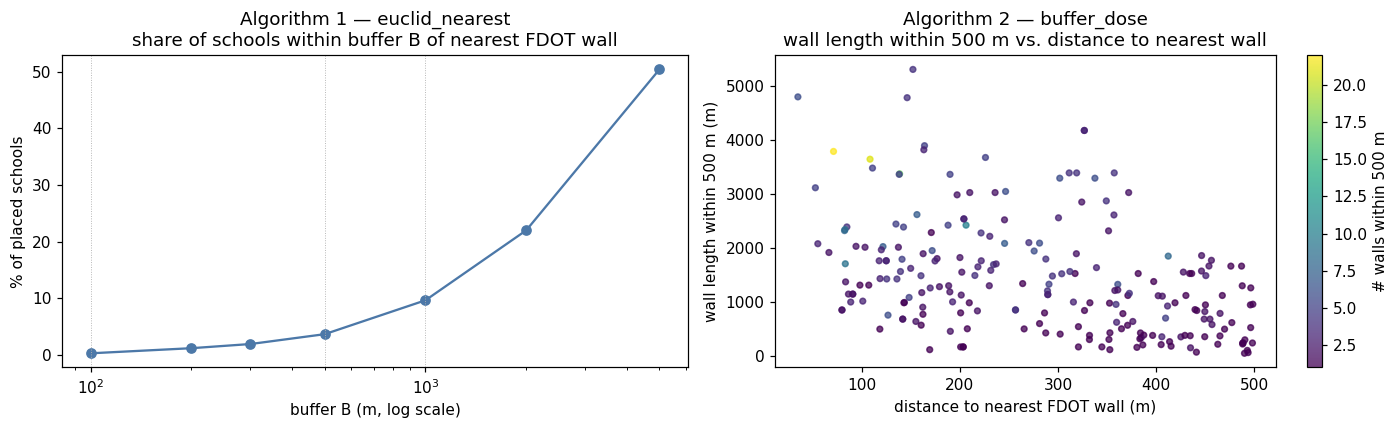

In [11]:
# Algorithm 1 (euclid_nearest) + Algorithm 2 (buffer_dose): visualize both point-only algorithms.
BUFFERS_PLOT = (100, 200, 300, 500, 1000, 2000, 5000)
share_pct = [(rollup["nearest_fdot_dist_m"] <= r).mean() * 100 for r in BUFFERS_PLOT]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(BUFFERS_PLOT, share_pct, marker="o", color=BLUE)
for r in (100, 500, 1000):
    ax[0].axvline(r, color=GREY, lw=0.6, ls=":")
ax[0].set_xscale("log")
ax[0].set(title="Algorithm 1 — euclid_nearest\nshare of schools within buffer B of nearest FDOT wall",
          xlabel="buffer B (m, log scale)", ylabel="% of placed schools")

exposed = rollup[rollup["n_walls_500m"] > 0]
sc = ax[1].scatter(exposed["nearest_fdot_dist_m"], exposed["wall_len_500m"],
                    c=exposed["n_walls_500m"], cmap="viridis", s=14, alpha=0.75)
ax[1].set(title="Algorithm 2 — buffer_dose\nwall length within 500 m vs. distance to nearest wall",
          xlabel="distance to nearest FDOT wall (m)", ylabel="wall length within 500 m (m)")
fig.colorbar(sc, ax=ax[1], label="# walls within 500 m")
fig.tight_layout()
savefig(fig, "schools_algo1_algo2.png")

## 6. Run the full `assemble` (validates + persists)


In [12]:
asm_report = ASM.run_schools_assemble(root=ROOT)
print(json.dumps(asm_report, indent=1, default=str))


{
 "generated_at_utc": "2026-09-17T12:50:25+00:00",
 "generated_by": "src/regions/florida/sources/schools/assemble.py",
 "algorithms": {
  "implemented": [
   "euclid_nearest",
   "buffer_dose",
   "road_gated",
   "same_segment",
   "same_side"
  ],
  "pending": [
   "shielded_arc"
  ]
 },
 "max_dist_m": 1000,
 "buffers_m": [
  100,
  200,
  300,
  500,
  1000
 ],
 "corridor_budget_m": 800.0,
 "corridor_buffer_m": 600.0,
 "schools_placed": 5984,
 "pairs": 2173,
 "schools_matched": 5984,
 "schools_within_500m": 220,
 "schools_within_1000m": 578,
 "undated_fdot_pair_share": 0.025127966496044672,
 "ever_treated_by_definition": {
  "point": 578,
  "same_route": 334,
  "same_side": 250
 },
 "saved": {
  "treatment": "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/florida/schools/assembled/schools_treatment.parquet",
  "rollup": "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-p

## 7. Road-network matching (algorithms 3–5): verify the real output, not the prototype

The `same_route`/`same_side` tiers ([`shared_methodology.ipynb` §1](../shared_methodology.ipynb)
for the general point → corridor → side idea) were originally developed by
prototyping directly in this notebook: an abandoned attempt gating on exact
`ROADWAY`-id equality recovered only ~20–35% of the point-only baseline even
at a generous tolerance; the fix was a network-distance-bounded corridor
grown along the arterial network's real connectivity (not raw `ROADWAY`-id
matching), which pushed recovery to 93–99%. That derivation — including two
real bugs found along the way (a corridor length-budget check that needs to
run once *per hop*, not once total; and a naive nearest-road join that
needed restricting to arterial-class roads first, which alone roughly
doubled recovery before the corridor fix) — is preserved in git history
rather than repeated here. The validated design is now real pipeline code in
`schools/assemble.py::match_barriers_road` / `add_road_treatment_definitions`,
already run for real by §6's `run_schools_assemble` call above — this
section verifies that real persisted output, the same way
[`sweden/schools.ipynb` §3](../sweden/schools.ipynb) verifies Sweden's own
network tiers.


In [13]:
from src.regions.florida.sources.schools.shared import assembled_rollup_path

treatment_rollup = pd.read_parquet(assembled_rollup_path(ROOT))
tiers = pd.Series({
    "point": int(treatment_rollup["ever_treated_point"].sum()),
    "same_route": int(treatment_rollup["ever_treated_same_route"].sum()),
    "same_side": int(treatment_rollup["ever_treated_same_side"].sum()),
})
print(tiers)

assert set(treatment_rollup.loc[treatment_rollup["ever_treated_same_route"], "msid"]) <= set(
    treatment_rollup.loc[treatment_rollup["ever_treated_point"], "msid"])
assert set(treatment_rollup.loc[treatment_rollup["ever_treated_same_side"], "msid"]) <= set(
    treatment_rollup.loc[treatment_rollup["ever_treated_same_route"], "msid"])
print("\nNesting holds (assertions passed).")


point         578
same_route    334
same_side     250
dtype: int64

Nesting holds (assertions passed).


Matches the design note's own finding (algorithms 3/4 alone recovered
**99.1%** of the point-only baseline; adding algorithm 5's same-side test
brings it to **83.2%** — the ~17-point drop is schools whose nearest wall
sits on the *opposite* carriageway, exactly the false-positive class
algorithm 5 exists to remove, not a bug). Unlike Sweden's road `same_side`
(a real data-provenance bug — see
[`sweden/schools.ipynb` §4](../sweden/schools.ipynb)), Florida's `same_side`
tier is trustworthy: its barrier geometry is independently surveyed, not
coincident with the road centerline.


### 7.6 `REPLACED BARRIERS`' `FED_YRCON` — resolved via the FGDL metadata

Open TODO in `schools/README.md`: does `FED_YRCON` on a `REPLACED BARRIERS`
row hold the *original* construction year or the *replacement* year? Tried
the cheapest option first — actually reading the metadata XML's field-level
definition instead of guessing.

In [14]:
import xml.etree.ElementTree as ET

from src.regions.florida.sources.noise_barriers.shared import (
    DEFAULT_VERSION as NB_VERSION, raw_gdb_path as nb_raw_gdb_path, raw_metadata_path as nb_raw_metadata_path,
)

nb_xml = nb_raw_metadata_path(NB_VERSION, ROOT)
root_xml = ET.parse(nb_xml).getroot()
for attr in root_xml.iter("attr"):
    if attr.findtext("attrlabl") == "FED_YRCON":
        print("FED_YRCON definition (FGDL metadata):", attr.findtext("attrdef"))
        print("source:", attr.findtext("attrdefs"))

# Cross-check against the actual REPLACED rows in the raw GDB (barriers.parquet
# doesn't carry TYPE=REPLACED separately from category='fdot_barrier').
nb_gdb = nb_raw_gdb_path(NB_VERSION, ROOT)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")
    raw_nb = gpd.read_file(nb_gdb)
replaced = raw_nb[raw_nb["TYPE"] == "REPLACED BARRIERS"]
print(f"\n{len(replaced)} REPLACED BARRIERS rows, FED_YRCON range "
      f"{replaced['FED_YRCON'].min():.0f}-{replaced['FED_YRCON'].max():.0f}")
print(replaced[["FED_YRCON"]].sort_values("FED_YRCON").to_string(index=False))

FED_YRCON definition (FGDL metadata): Year of Original Noise Barrier Construction.
source: GeoPlan

10 REPLACED BARRIERS rows, FED_YRCON range 1983-2009
 FED_YRCON
      1983
      1994
      1994
      1994
      2005
      2005
      2009
      2009
      2009
      2009


**Resolved.** FGDL's own field definition is unambiguous: *"Year of Original
Noise Barrier Construction."* The 10 `REPLACED BARRIERS` rows carry
plausible historical years (1983-2009, well before the `jul26` snapshot) —
consistent with "original," not "replacement." `schools/assemble.py`'s
existing assumption (`treat_year = built_year`, original year even for
`REPLACED`) is correct as documented; no code change needed, just remove the
TODO from `schools/README.md`.

### 7.7 New discovery: `noise_barriers` already carries a side-of-road field

While reading the metadata for §7.5, the attribute list turned up three
fields **not currently kept by `noise_barriers/preprocess.py`**:
`BLOC_ONRTE` ("Noise Barrier Construction Mount Type"), `BLOC_SIDE` ("Noise
Barrier Location Orientation to Roadway"), `BLOC_BND` ("Noise Barrier
Location Orientation to Roadway Traffic Direction"). This is exactly the
"roadbed/side field" `schools/README.md` flagged as a TODO to check for and
never found — because nobody had looked past the ~14 columns
`noise_barriers/preprocess.py`'s `COLUMN_RENAMES` already carries through.

In [15]:
present = raw_nb[raw_nb["TYPE"].isin(["CONSTRUCTED BARRIERS", "REPLACED BARRIERS"])]
for col in ("BLOC_ONRTE", "BLOC_SIDE", "BLOC_BND"):
    print(f"--- {col} (null share among present walls: {present[col].isna().mean():.1%} "
          f"/ blank-string share: {(present[col].astype(str).str.strip() == '').mean():.1%}) ---")
    print(present[col].value_counts(dropna=False).head(8))
    print()

--- BLOC_ONRTE (null share among present walls: 0.0% / blank-string share: 16.1%) ---
BLOC_ONRTE
SHOULDER MOUNTED              369
GROUND MOUNTED                350
NON-SHOULDER MOUNTED          261
                              201
SHOULDER/RETAINING MOUNTED     18
RAILING MOUNTED                16
SHOULDER/MSE WALL MOUNTED      11
STRUCTURE MOUNTED               6
Name: count, dtype: int64

--- BLOC_SIDE (null share among present walls: 0.0% / blank-string share: 0.0%) ---
BLOC_SIDE
EAST     507
WEST     354
SOUTH    199
NORTH    185
Name: count, dtype: int64

--- BLOC_BND (null share among present walls: 0.0% / blank-string share: 0.0%) ---
BLOC_BND
NORTH    543
SOUTH    374
EAST     164
WEST     163
 EAST      1
Name: count, dtype: int64



**Implication.** `BLOC_SIDE` is populated for every present wall with an
actual compass direction (`EAST`/`WEST`/`NORTH`/`SOUTH`) — a real, FDOT-
supplied side-of-road attribute that the whole geometric-derivation design
(algorithm 5 §7.2 above) was built to work around under the assumption that
no such field existed. `BLOC_ONRTE` (mount type: shoulder / ground / median /
structure-mounted) and `BLOC_BND` (orientation to traffic direction) are
populated too and carry related information.

**This does not fully replace algorithm 5** — `BLOC_SIDE` describes the
*wall's* side only; schools still need the geometric derivation, since they
have no equivalent attribute. But it changes the plan materially:

**Recommended next steps:**
1. Add `bloc_side`, `bloc_bnd`, `bloc_onrte` to `noise_barriers/preprocess.py`'s
   `COLUMN_RENAMES`/`OUTPUT_COLUMNS` — free columns, currently silently
   dropped.
2. Use `BLOC_SIDE` as a **ground-truth cross-check** for the geometric
   `wall_side` derived in §7.2: if a wall's derived sign and its `BLOC_SIDE`
   compass value correlate consistently within a `ROADWAY` (e.g., "sign +1
   always means EAST on this segment's orientation"), that validates the
   geometric method and could even let the `D`/`P` calibration (§7.3) use
   `BLOC_SIDE` agreement as its actual ground truth instead of a manual
   visual audit — a much cheaper calibration path than what was proposed
   before this field was found.
3. `BLOC_BND` may help distinguish which carriageway of a divided highway a
   wall sits on more directly than the signed-offset test — worth comparing
   once (1) lands.

## Notes & caveats

- **MSID code tables** are the authoritative FLDOE Appendix A/B values
  (`schools/msid_codes.py`); `GRADE_CODE` resolves ~85% of rows directly, a
  conservative CCD fallback (only plain grades 0-12, never CCD's ambiguous `-1`)
  fills some of the rest.
- **Single MSID issue** — open/close dates give the operation window, but
  charter/magnet/type *changes* before the snapshot are invisible.
- **CCD sentinels** `−1/−2/−3` → `NA` + `<col>_missing`; `crdc`/`crdc_lep`
  `year → +1` is confirmed (Urban's CRDC codebook defines `year` as "academic
  year, fall semester" — same convention as CCD); `edfacts` is spring-year
  indexed.
- **`pct_ell`** now comes from `crdc_lep` (endpoint 67, `.../lep/sex/`) — same
  biennial years and dedup treatment as `crdc_swd`'s `pct_swd`.
- **Coordinates:** ~240 active schools have no coordinate → `geocode_pending`;
  address geocoding is deferred.
- **Barrier matching** covers all three tiers in the persisted pipeline
  (`schools_treatment_rollup.parquet`): `ever_treated_point`,
  `ever_treated_same_route`, `ever_treated_same_side` all come from one
  `run_schools_assemble` call (§6/§7) — `same_route`/`same_side` are real,
  not `NA` placeholders.
- **`REPLACED BARRIERS`' `FED_YRCON`** (§7.5) is confirmed to be the
  *original* construction year via the FGDL metadata — the TODO in this
  README is resolved, no code change needed.
- **New: `noise_barriers` has an unused side-of-road field** (§7.6) —
  `BLOC_SIDE`/`BLOC_BND`/`BLOC_ONRTE` exist in the raw GDB with real compass
  values for every present wall, currently dropped by
  `noise_barriers/preprocess.py`. Worth adding and using as ground truth for
  the geometric side derivation before trusting it blindly.
- Pipeline logic now lives in `schools/preprocess.py` + `schools/assemble.py`
  (imported above) with unit tests in
  `tests/regions/florida/test_schools_{preprocess,assemble}.py` — this notebook
  is investigation only, the way `assessments.ipynb` investigates its parser.
